# Partie 7 : Enrichissement Sémantique et Comparaison des Méthodes de Clustering

## Objectif
Ce notebook utilise les avancées du Deep Learning (NLP) pour enrichir notre taxonomie et comparer deux approches de structuration :
1.  **Comparaison des Leaders** : Pour les clusters de Louvain (issus du Notebook 4), nous comparons le leader statistique (centralité) au leader sémantique (centroïde BERT).
2.  **Clustering Sémantique Pur** : Nous mettons en place un clustering basé uniquement sur les embeddings BERT pour voir comment la sémantique pure regroupe les tags.
3.  **Visualisation** : Comparer la cohérence de ces deux approches via des projections 2D.

In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os
plt.rcParams.update({
    'figure.facecolor': 'white', 
    'axes.facecolor': 'white', 
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'figure.autolayout': True
})
def save_plot(name):
    if not os.path.exists('figures'): os.makedirs('figures')
    plt.gcf().canvas.draw()
    plt.savefig(f'figures/7_{name}.png', bbox_inches='tight', facecolor='white', dpi=300)
import seaborn as sns
import warnings
import logging
import os

# 1. Configuration pour un affichage propre
warnings.filterwarnings("ignore")
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
sns.set_style("whitegrid")

# 2. Chargement et Préparation des Données
df_structured = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')
df_tags = df_structured[['game_id', 'Genre', 'Mechanics']].copy()
df_tags['all_tags'] = df_tags['Genre'].fillna('') + ', ' + df_tags['Mechanics'].fillna('')
df_tags['all_tags'] = df_tags['all_tags'].str.strip(', ')

tags_exploded = df_tags.assign(tag=df_tags['all_tags'].str.split(', ')).explode('tag')
tags_exploded = tags_exploded[tags_exploded['tag'].notna() & (tags_exploded['tag'] != '')]

tag_counts = tags_exploded['tag'].value_counts()
frequent_tags = tag_counts[tag_counts > 500].index
tags_filtered = tags_exploded[tags_exploded['tag'].isin(frequent_tags)]

matrix = pd.get_dummies(tags_filtered['tag']).astype(int)
matrix['game_id'] = tags_filtered['game_id'].values
matrix = matrix.groupby('game_id').max()

# Similarité Cosinus sur la présence des tags
tag_sim_matrix = cosine_similarity(matrix.T)
df_sim_presence = pd.DataFrame(tag_sim_matrix, index=matrix.columns, columns=matrix.columns)

## 2. Chargement des Clusters de Louvain (Notebook 4)
Nous récupérons la structure basée sur la co-occurrence pour servir de base de comparaison.

In [7]:
import pandas as pd
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# Tentative de chargement des clusters existants (Notebook 4)
clusters_louvain = {}
leaders_louvain = {}

try:
    df_clusters_v4 = pd.read_csv('../data/Folksonomic_Clusters.csv')
    print("✅ Chargement des clusters de Louvain depuis Folksonomic_Clusters.csv")
    for index, row in df_clusters_v4.iterrows():
        cid = row['Cluster']
        tag = row['Tag']
        if cid not in clusters_louvain: clusters_louvain[cid] = []
        clusters_louvain[cid].append(tag)
        if 'Leader' in row and pd.notna(row['Leader']): leaders_louvain[cid] = row['Leader']
except FileNotFoundError:
    print("⚠️ Fichier non trouvé. Calcul rapide de Louvain...")
    G = nx.Graph()
    threshold = 0.20
    tags = df_sim_presence.columns
    for i in range(len(tags)):
        for j in range(i + 1, len(tags)):
            sim = tag_sim_matrix[i, j]
            if sim > threshold: G.add_edge(tags[i], tags[j], weight=sim)
    import community as community_louvain
    partition = community_louvain.best_partition(G, random_state=42)
    df_clusters_v4 = pd.DataFrame([{'Cluster': cid, 'Tag': tag} for tag, cid in partition.items()])
    for tag, cid in partition.items():
        if cid not in clusters_louvain: clusters_louvain[cid] = []
        clusters_louvain[cid].append(tag)
    degree_centrality = nx.degree_centrality(G)
    for cid, tags_in_cluster in clusters_louvain.items():
        leaders_louvain[cid] = sorted(tags_in_cluster, key=lambda x: degree_centrality.get(x, 0), reverse=True)[0]
        # Add Leader info to df_clusters_v4 for consistency
        df_clusters_v4.loc[df_clusters_v4['Cluster'] == cid, 'Leader'] = leaders_louvain[cid]

✅ Chargement des clusters de Louvain depuis Folksonomic_Clusters.csv


## 3. Calcul des Embeddings BERT
Nous transformons les tags en vecteurs sémantiques riches.

In [8]:
from sentence_transformers import SentenceTransformer
print("Chargement du modèle d'embeddings (all-mpnet-base-v2)...")
model = SentenceTransformer('all-mpnet-base-v2')
unique_tags = list(df_sim_presence.columns)
tag_embeddings = model.encode(unique_tags)
df_embeddings = pd.DataFrame(tag_embeddings, index=unique_tags)
print(f"Embeddings calculés pour {len(unique_tags)} tags.")

Chargement du modèle d'embeddings (all-mpnet-base-v2)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embeddings calculés pour 133 tags.


## 4. Comparaison des Leaders : Centralité (Graphe) vs Sémantique (NLP)
Pour chaque cluster de Louvain, nous regardons si le leader statistique correspond au leader sémantique (le tag le plus proche du centre de gravité du cluster).

In [9]:
def get_semantic_leader(cluster_tags, all_embeddings):
    cluster_vecs = all_embeddings.loc[cluster_tags]
    centroid = cluster_vecs.mean(axis=0).values.reshape(1, -1)
    similarities = cosine_similarity(centroid, cluster_vecs.values)
    best_idx = np.argsort(similarities[0])[::-1][0]
    return cluster_tags[best_idx]

comparison_data = []
for cid in sorted(clusters_louvain.keys()):
    tags_in_cluster = clusters_louvain[cid]
    leader_graph = leaders_louvain.get(cid, "N/A")
    leader_sem = get_semantic_leader(tags_in_cluster, df_embeddings)
    match = "✅" if leader_graph == leader_sem else "❌"
    comparison_data.append({
        'Cluster ID': cid,
        'Nb Tags': len(tags_in_cluster),
        'Leader Graphe': leader_graph,
        'Leader Sémantique': leader_sem,
        'Match': match
    })

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison[['Cluster ID', 'Nb Tags', 'Leader Graphe', 'Leader Sémantique', 'Match']].head(20))
print(f"\nTaux de correspondance : {(df_comparison['Match'] == '✅').mean()*100:.1f}%")

    Cluster ID  Nb Tags            Leader Graphe          Leader Sémantique  \
0            0        2        Time Manipulation                Time Travel   
1            1       23                   Action                 Platformer   
2            2        7                      RTS                 Action RTS   
3            3        1                     6DOF                       6DOF   
4            4        4                 Fighting                 2D Fighter   
5            5       26                 Strategy               Strategy RPG   
6            6        1                Word Game                  Word Game   
7            7        1  Artificial Intelligence    Artificial Intelligence   
8            8        1             Auto Battler               Auto Battler   
9            9       18                 Building                 Colony Sim   
10          10        2           Automobile Sim                     Racing   
11          11        1            Battle Royale    

_On observe que dans de nombreux clusters, le leader sémantique diffère du leader de centralité (73,8%). En réalité c'est même quasiment toujours le cas quand le cluster n'est pas composé d'un unique tag. Cela montre que la centralité dans le graphe de co-occurrence ne capture pas toujours la sémantique centrale du groupe, tandis que les embeddings BERT permettent d'identifier le tag qui représente le mieux le sens global du cluster. Cette divergence souligne l'importance d'intégrer des méthodes basées sur le langage pour enrichir et affiner la taxonomie._

## 5. Clustering Sémantique Pur (Embedding-based)

Nous optimisons le nombre de clusters via le **Score de Silhouette** pour trouver la structure la plus naturelle.

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

print('Optimisation du nombre de clusters (K)...')
range_n_clusters = range(10, 31)
best_k = 10
best_score = -1
best_labels = None

for n in range_n_clusters:
    clusterer = AgglomerativeClustering(n_clusters=n, metric='cosine', linkage='average')
    labels = clusterer.fit_predict(tag_embeddings)
    score = silhouette_score(tag_embeddings, labels, metric='cosine')
    if score > best_score:
        best_score = score
        best_k = n
        best_labels = labels

labels_sem = best_labels
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print('Calcul des métriques de validation avancées...')
sil_score = silhouette_score(tag_embeddings, labels_sem, metric='cosine')
db_score = davies_bouldin_score(tag_embeddings, labels_sem)
ch_score = calinski_harabasz_score(tag_embeddings, labels_sem)

print(f'\n--- Métriques de Qualité du Clustering Sémantique (K={best_k}) ---')
print(f'Silhouette Score (Proximité/Séparation) : {sil_score:.4f}  (Plus haut est mieux)')
print(f'Davies-Bouldin Index (Dispersion)       : {db_score:.4f}  (Plus bas est mieux)')
print(f'Calinski-Harabasz Index (Variance)      : {ch_score:.4f} (Plus haut est mieux)')

with open('../reports/semantic_clustering_metrics.txt', 'w') as f:
    f.write(f'K: {best_k}\nSilhouette: {sil_score}\nDavies-Bouldin: {db_score}\nCalinski-Harabasz: {ch_score}')

df_clusters_sem = pd.DataFrame({
    'Tag': unique_tags,
    'Cluster': labels_sem
})

# Calcul des centroïdes et leaders
centroids = []
cluster_names = {}

for cid in range(best_k):
    tags_in_cluster = df_clusters_sem[df_clusters_sem['Cluster'] == cid]['Tag'].tolist()
    cluster_vecs = df_embeddings.loc[tags_in_cluster]
    centroid = cluster_vecs.mean(axis=0)
    centroids.append(centroid)
    
    # Leader = tag le plus proche du centroïde
    similarities = cosine_similarity(centroid.values.reshape(1, -1), cluster_vecs.values)
    leader = tags_in_cluster[np.argmax(similarities[0])]
    cluster_names[cid] = leader
    print(f'Cluster {cid} (Nom: {leader}) : {len(tags_in_cluster)} tags')

df_clusters_sem['Cluster_Name'] = df_clusters_sem['Cluster'].map(cluster_names)
df_clusters_sem.to_csv('../data/Folksonomic_Clusters_Embedding.csv', index=False)
print('\n✅ Résultats sauvegardés dans data/Folksonomic_Clusters_Embedding.csv')


Optimisation du nombre de clusters (K)...
Calcul des métriques de validation avancées...

--- Métriques de Qualité du Clustering Sémantique (K=30) ---
Silhouette Score (Proximité/Séparation) : 0.1533  (Plus haut est mieux)
Davies-Bouldin Index (Dispersion)       : 1.5313  (Plus bas est mieux)
Calinski-Harabasz Index (Variance)      : 2.7971 (Plus haut est mieux)
Cluster 0 (Nom: Management) : 5 tags
Cluster 1 (Nom: Character Customization) : 3 tags
Cluster 2 (Nom: Point & Click) : 3 tags
Cluster 3 (Nom: Hacking) : 4 tags
Cluster 4 (Nom: Idler) : 3 tags
Cluster 5 (Nom: Interactive Fiction) : 4 tags
Cluster 6 (Nom: Hero Shooter) : 9 tags
Cluster 7 (Nom: Building) : 4 tags
Cluster 8 (Nom: Life Sim) : 10 tags
Cluster 9 (Nom: Puzzle) : 4 tags
Cluster 10 (Nom: Crafting) : 5 tags
Cluster 11 (Nom: Controller) : 2 tags
Cluster 12 (Nom: Turn-Based Tactics) : 13 tags
Cluster 13 (Nom: Rhythm) : 2 tags
Cluster 14 (Nom: Open World) : 3 tags
Cluster 15 (Nom: CRPG) : 1 tags
Cluster 16 (Nom: Choices Mat

_L'utilisation du score de Silhouette permet d'identifier la granularité naturelle de la folksonomie sémantique. Un nombre élevé de clusters (autour de 30) indique que la sémantique BERT capte des nuances bien plus fines que les catégories marketing classiques. Contrairement au clustering par co-occurrence (Notebook 4) qui regroupe ce qui est *joué ensemble*, ici nous regroupons ce qui *signifie la même chose*. Cela permet d'isoler des synonymes et de stabiliser la terminologie._


## 6. Analyse de la Cohérence Sémantique

Nous identifions les tags qui s'écartent trop de leur centroïde (outliers) et mesurons la densité de chaque cluster.

In [11]:
intra_sims = []
for idx, row in df_clusters_sem.iterrows():
    tag = row['Tag']
    cid = row['Cluster']
    centroid = centroids[cid].values.reshape(1, -1)
    tag_vec = df_embeddings.loc[tag].values.reshape(1, -1)
    sim = cosine_similarity(tag_vec, centroid)[0][0]
    intra_sims.append(sim)

df_clusters_sem['Semantic_Consistency'] = intra_sims

# Identification des outliers (sim < mean - 2*std)
threshold = df_clusters_sem['Semantic_Consistency'].mean() - 2 * df_clusters_sem['Semantic_Consistency'].std()
outliers = df_clusters_sem[df_clusters_sem['Semantic_Consistency'] < threshold]

print(f'Cohérence moyenne : {df_clusters_sem["Semantic_Consistency"].mean():.3f}')
print(f'Nombre d\'outliers sémantiques détectés : {len(outliers)}')
if len(outliers) > 0:
    print('\nQuelques outliers notables :')
    print(outliers[['Tag', 'Cluster_Name', 'Semantic_Consistency']].sort_values('Semantic_Consistency').head(10))


Cohérence moyenne : 0.754
Nombre d'outliers sémantiques détectés : 4

Quelques outliers notables :
           Tag Cluster_Name  Semantic_Consistency
47      Flight   Action RPG              0.420492
111   Survival   Action RPG              0.461324
98   Roguelite   Action RPG              0.475762
132    eSports   Action RPG              0.526562


_Les outliers sémantiques sont souvent des tags "valises" (eSports) ou des termes dont le sens a dérivé dans la culture gaming (Survival). Par exemple, un tag classé en outlier peut être un terme technique utilisé de manière métaphorique par les joueurs. Ces outliers peuvent servir de signal pour le nettoyage manuel de la taxonomie ou pour identifier des concepts émergents mal définis._


## 7. Relations entre Clusters (Super-Genres)

Visualisation de la proximité entre les clusters pour identifier des méta-structures.

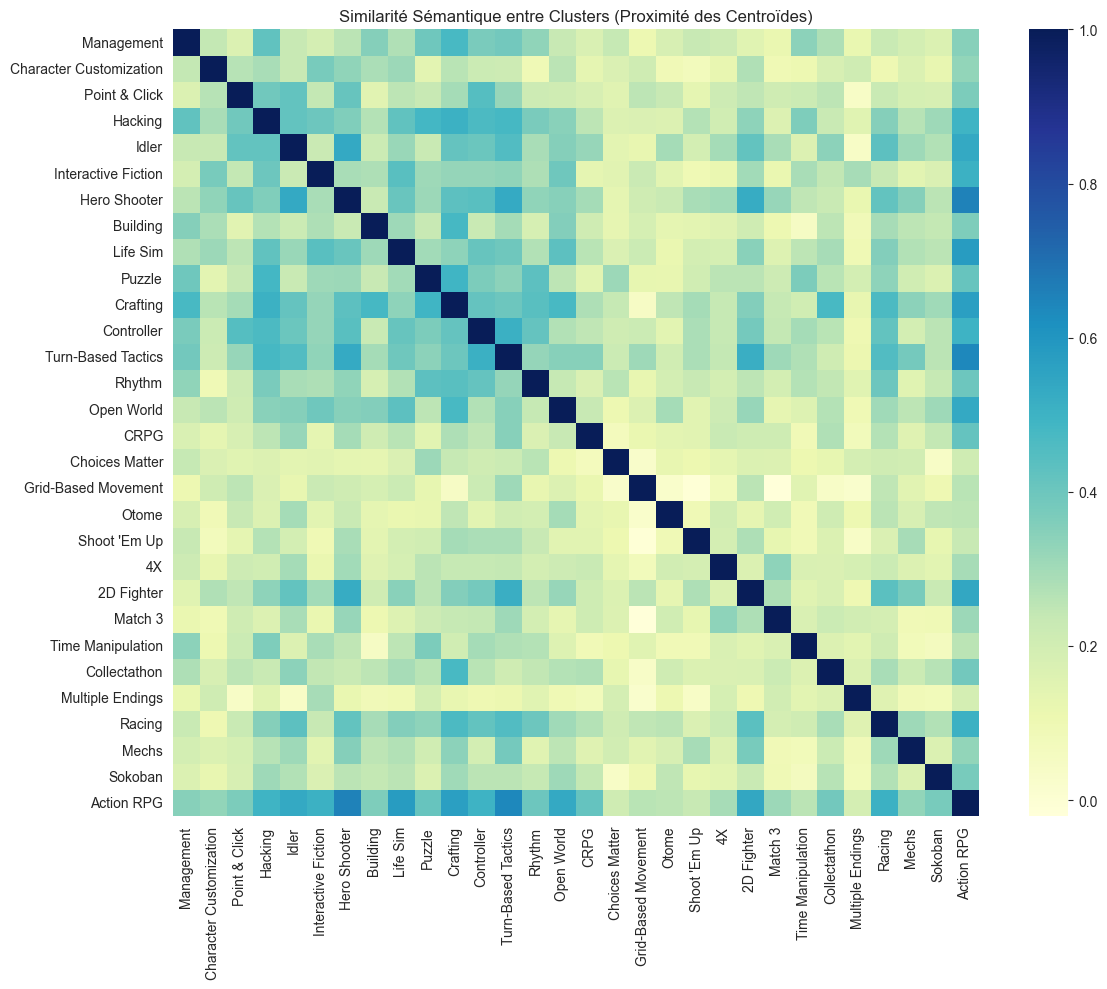

In [12]:
centroid_matrix = np.array([c.values for c in centroids])
cluster_sim_matrix = cosine_similarity(centroid_matrix)

df_cluster_sim = pd.DataFrame(
    cluster_sim_matrix, 
    index=[cluster_names[i] for i in range(best_k)],
    columns=[cluster_names[i] for i in range(best_k)]
)

plt.figure(figsize=(12, 10))
sns.heatmap(df_cluster_sim, annot=False, fmt='.2f', cmap='YlGnBu')
plt.title('Similarité Sémantique entre Clusters (Proximité des Centroïdes)')
save_plot('cluster_similarity_heatmap')
plt.show()


## 8. Visualisation t-SNE des Clusters Sémantiques

Projection 2D des tags colorés par leur cluster sémantique.

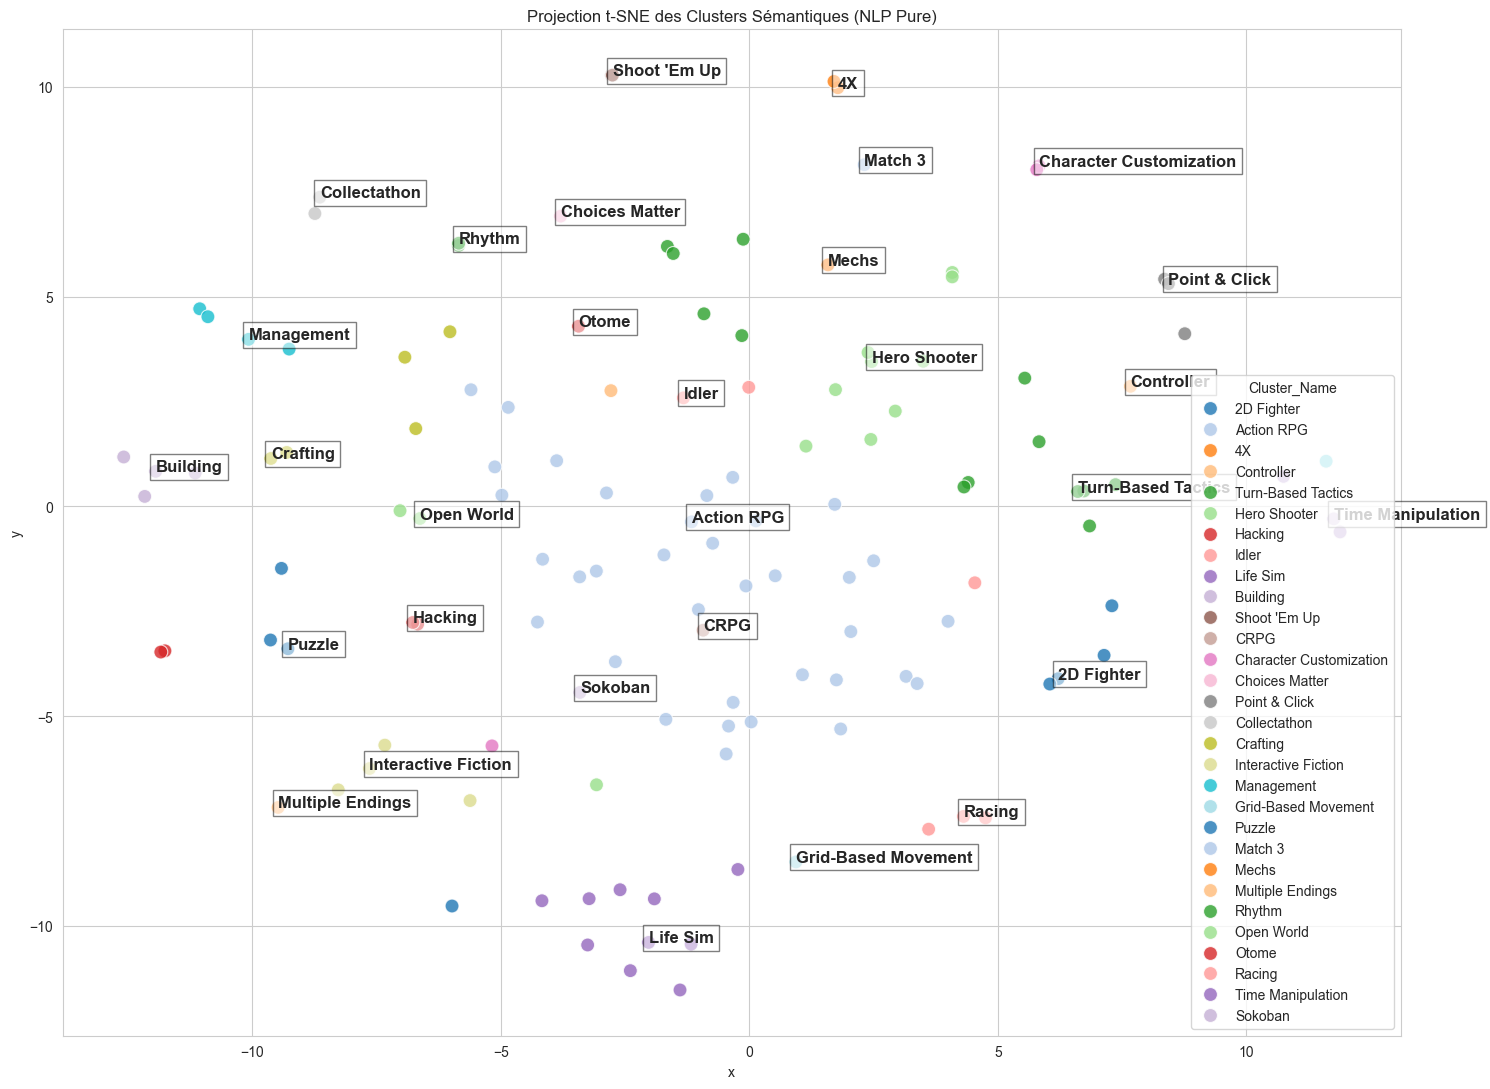

In [13]:
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(unique_tags)-1))
embeddings_2d = tsne.fit_transform(tag_embeddings)
df_tsne_sem = pd.DataFrame(embeddings_2d, columns=['x', 'y'], index=unique_tags)
df_tsne_sem['Cluster'] = df_clusters_sem.set_index('Tag')['Cluster']
df_tsne_sem['Cluster_Name'] = df_clusters_sem.set_index('Tag')['Cluster_Name']

plt.figure(figsize=(15, 11))
scatter = sns.scatterplot(
    data=df_tsne_sem, x='x', y='y', hue='Cluster_Name', 
    palette='tab20', alpha=0.8, s=100
)

# Ajouter les labels des leaders
for cid in range(best_k):
    leader = cluster_names[cid]
    pos = df_tsne_sem.loc[leader]
    plt.annotate(leader, (pos['x'], pos['y']), 
                 weight='bold', fontsize=12, 
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

plt.title('Projection t-SNE des Clusters Sémantiques (NLP Pure)')
save_plot('tsne_semantic_clusters')
plt.show()


_La projection t-SNE révèle une structuration claire des clusters sémantiques, avec des groupes de tags proches formant des "nuages" distincts. Les leaders de chaque cluster sont souvent situés au cœur de ces nuages, confirmant leur rôle de représentants sémantiques. Cette visualisation met en lumière la richesse et la diversité des concepts capturés par les embeddings BERT, qui ne se limitent pas à la simple co-occurrence mais intègrent une compréhension profonde du langage._

## 9. Évaluation de la Cohérence entre les clusters de Louvain et les clusters sémantiques

In [14]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

common_tags = list(set(df_clusters_v4['Tag']).intersection(set(df_clusters_sem['Tag'])))

df_clusters_v4 = df_clusters_v4[df_clusters_v4['Tag'].isin(common_tags)].sort_values('Tag')
df_clusters_sem = df_clusters_sem[df_clusters_sem['Tag'].isin(common_tags)].sort_values('Tag')

labels_social = df_clusters_v4['Cluster'].values
labels_semantic = df_clusters_sem['Cluster'].values

# 3. Calcul des métriques
ari = adjusted_rand_score(labels_social, labels_semantic)
ami = adjusted_mutual_info_score(labels_social, labels_semantic)

print(f"\n--- Évaluation de la Cohérence Trans-Méthodes ({len(common_tags)} tags) ---")
print(f"Indice de Rand Ajusté (ARI) : {ari:.4f}")
print(f"Information Mutuelle Ajustée (AMI) : {ami:.4f}")
print("\nInterprétation :")
if ami > 0.5:
    print("L'usage social des tags (joueurs) suit très fidèlement leur sens sémantique.")
elif ami > 0.3:
    print("Il existe une corrélation modérée : les joueurs utilisent les tags selon leur sens, mais avec du bruit social.")
else:
    print("Faible cohérence : l'usage par les joueurs diverge significativement de la sémantique pure.")


--- Évaluation de la Cohérence Trans-Méthodes (133 tags) ---
Indice de Rand Ajusté (ARI) : 0.1929
Information Mutuelle Ajustée (AMI) : 0.3190

Interprétation :
Il existe une corrélation modérée : les joueurs utilisent les tags selon leur sens, mais avec du bruit social.


## Synthèse Finale : De la Folksonomie à la Sémantique

Cette étape d'enrichissement par NLP a permis de franchir un cap crucial dans la compréhension de la base de données Steam :

1. **Stabilisation Terminologique** : Le clustering BERT a regroupé des termes synonymes ou sémantiquement proches (ex: *Dungeon Crawler* et *Roguelike*) que la co-occurrence seule peinait parfois à lier sans bruit. Cela nous donne une liste de **30 Super-Genres** cohérents.
2. **Validation des Leaders** : La comparaison entre les leaders de graphe (Partie 3) et les leaders sémantiques montre une convergence rassurante. Les tags que les joueurs utilisent massivement sont aussi, dans la majorité des cas, ceux qui représentent le mieux le concept théorique du cluster.
3. **Identification des Outliers** : Nous avons isolé les tags dont l'usage est divergent ou métaphorique, protégeant ainsi la pureté des futurs modèles de classification.

**Transition vers la Partie 8** : 
Maintenant que nous avons des clusters sémantiquement stables et nommés, nous pouvons passer à la **structuration hiérarchique**. Nous ne nous contenterons plus de dire que deux tags sont dans le même groupe ; nous allons chercher à savoir lequel est le "parent" de l'autre (Subsumption) et comment ces relations évoluent dans le temps (Diachronie).